# Discovery — Air Quality (Kampala & Nairobi)

**By the end of this notebook, you will be able to:**
- Use matplotlib's object-oriented API (`fig, ax = plt.subplots()`) to build a chart step by step
- Use seaborn to get statistically-aware plots (grouping, confidence intervals) in a single call
- Use a correlation heatmap to get a first impression of which variables might matter

**Context:** PM2.5 (particulate matter under 2.5 micrometers) is one of the most dangerous forms of air pollution — small enough to reach deep into the lungs and bloodstream. Ground sensors are scarce in African cities, so this dataset pairs ground PM2.5 measurements with satellite readings (Sentinel-5P) for two cities, Kampala and Nairobi.

Before building anything, take the time to look at the data. Each section below introduces a plotting tool, then asks you to use it. There is no single correct **interpretation** here — the goal is to build hypotheses you can reuse later, not to produce reusable code.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CITIES = ["Kampala", "Nairobi"]
COLUMNS = [
    "city", "date", "hour", "site_latitude", "site_longitude", "pm2_5",
    "sulphurdioxide_so2_column_number_density",
    "carbonmonoxide_co_column_number_density",
    "nitrogendioxide_no2_column_number_density",
    "formaldehyde_tropospheric_hcho_column_number_density",
    "uvaerosolindex_absorbing_aerosol_index",
    "ozone_o3_column_number_density",
    "uvaerosollayerheight_aerosol_height",
    "cloud_cloud_fraction",
]

df = pd.read_csv("../../data/train.csv")
df = df[df["city"].isin(CITIES)][COLUMNS].copy()
df["date"] = pd.to_datetime(df["date"])
df.head(10)

,city,date,hour,site_latitude,site_longitude,pm2_5,sulphurdioxide_so2_column_number_density,carbonmonoxide_co_column_number_density,nitrogendioxide_no2_column_number_density,formaldehyde_tropospheric_hcho_column_number_density,uvaerosolindex_absorbing_aerosol_index,ozone_o3_column_number_density,uvaerosollayerheight_aerosol_height,cloud_cloud_fraction
34,Nairobi,2023-05-01,10,-1.243396,36.886487,7.731000,NaN,NaN,NaN,NaN,-1.278414,0.120399,NaN,NaN
35,Nairobi,2023-05-02,11,-1.243396,36.886487,15.827000,NaN,0.020761,0.000059,NaN,-0.272432,0.122059,NaN,0.512344
36,Nairobi,2023-05-03,11,-1.243396,36.886487,9.773000,NaN,NaN,NaN,NaN,-0.928581,0.122360,NaN,NaN
37,Nairobi,2023-05-04,10,-1.243396,36.886487,6.091579,0.000106,0.022391,0.000053,0.000038,-0.277613,0.119561,NaN,0.236829
38,Nairobi,2023-05-05,10,-1.243396,36.886487,11.162000,-0.000247,0.026702,0.000062,0.000147,-0.595852,0.118729,NaN,0.009104
39,Nairobi,2023-05-06,10,-1.243396,36.886487,12.109000,NaN,0.023337,NaN,0.000224,-0.927360,0.118413,NaN,0.377096
40,Nairobi,2023-05-07,11,-1.243396,36.886487,11.603000,NaN,0.024513,NaN,NaN,0.807224,0.118558,NaN,0.519518
41,Nairobi,2023-05-08,11,-1.243396,36.886487,11.776500,NaN,0.023774,0.000054,0.000078,-0.464561,0.119281,NaN,0.387196
42,Nairobi,2023-05-09,11,-1.243396,36.886487,12.751333,NaN,0.022724,NaN,NaN,-0.395317,0.121159,NaN,NaN
43,Nairobi,2023-05-11,10,-1.243396,36.886487,9.983000,NaN,0.029227,NaN,NaN,-0.956737,0.122179,NaN,0.721127


## 1. Getting to know your tools: matplotlib

matplotlib is the foundational Python plotting library — most other libraries, including seaborn, build on top of it. Its core object-oriented pattern is always the same three steps:

1. `fig, ax = plt.subplots()` creates a **figure** (the whole image) and one or more **axes** (an individual plot area) to draw on.
2. Call methods directly on `ax` to draw — `ax.hist(...)`, `ax.plot(...)`, `ax.bar(...)` — and to label it — `ax.set_xlabel(...)`, `ax.legend(...)`.
3. `plt.show()` displays the result.

Everything else (colors, styles, subplots) is a variation on this pattern.

**Documentation references:**
- [Matplotlib quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)
- [`Axes.hist()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)

**Exercise:** You will compare the `pm2_5` distribution between the two cities. Rather than writing the plotting code twice (once per city), write a function that plots a `pm2_5` histogram for **one** city on a given `ax`. This "write the per-item logic once" pattern will come back throughout the notebook.

In [4]:
# TODO 1: define a function that plots a pm2_5 histogram for one city on a given ax
def plot_pm25_histogram(df, city, ax):
    """
    Plot a histogram of pm2_5 for one city on the given matplotlib Axes.

    Parameters:
    - df: DataFrame containing at least 'city' and 'pm2_5'
    - city: name of the city to filter on
    - ax: matplotlib Axes to draw on
    """
    plot_data= df[df['city']==city]
    ax.hist(plot_data['pm2_5'].dropna(),bins=100,)
    return ax

**Exercise:** Now use your function: create a figure, call `plot_pm25_histogram` once per city so both distributions appear on the same axes, then label and show the figure.

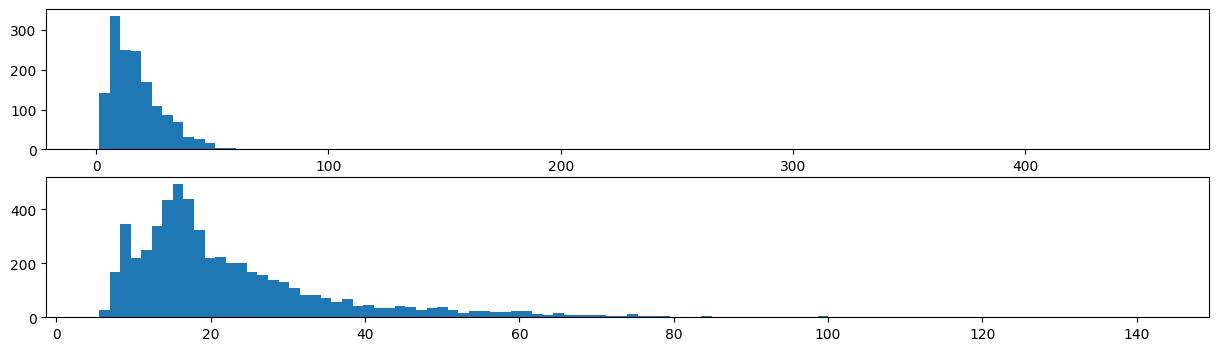

In [5]:
# TODO 2: create a figure, call plot_pm25_histogram once per city, label and show it

fig, axes = plt.subplots(2, 1, figsize=(15, 4))
axes.flatten()

plot_pm25_histogram(df, 'Nairobi', axes[0])
plot_pm25_histogram(df, 'Kampala', axes[1])
plt.show(fig)



## 2. A higher-level library: seaborn

seaborn is built on top of matplotlib but is designed for statistical plots and works directly with a DataFrame: instead of looping over cities and calling `ax.hist()` yourself, you pass `data=df` and tell seaborn which columns to use as `x`, `y`, or `hue` (the grouping/color variable) — it handles the split and the styling for you. Compare the histogram you just built by hand to its seaborn equivalent, in a single call, no loop:

```python
sns.displot(data=df, x="pm2_5", hue="city")
plt.title("PM2.5 distribution by city")
plt.show()
```

The trade-off: matplotlib gives you full manual control (useful for anything custom), seaborn gives you speed and good statistical defaults for common comparisons. The rest of this notebook keeps moving between the two, one step further each time.

**Documentation references:**
- [seaborn function overview](https://seaborn.pydata.org/tutorial/function_overview.html)
- [`seaborn.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html)
- [`seaborn.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

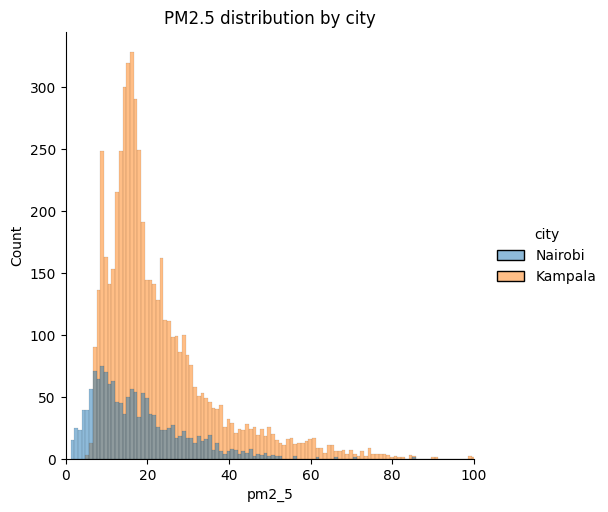

In [6]:
sns.displot(data=df, x="pm2_5", hue="city",bins=500)
plt.title("PM2.5 distribution by city")
plt.xlim(0,100)
plt.show()

**Exercise:** `displot` above already gave you the seaborn equivalent of the histogram. Go one step further with `seaborn.boxplot`, which compresses each city's distribution into its median, interquartile range, and outliers instead of showing every bin — a more compact summary, well suited to comparing two groups side by side. Following the `data=`/`x=`/`y=` pattern, figure out from [the function's documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html) which argument should carry the categories and which the values — and look at what else is available there (a color palette, showing the mean as well as the median...) to make the result easier to read, not just correct.

<Axes: xlabel='pm2_5'>

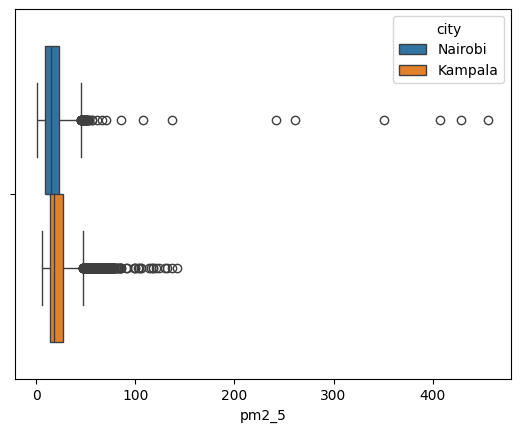

In [7]:
# TODO 3: go further than the histogram, with a seaborn.boxplot summarizing each city's
# distribution (median, interquartile range, outliers)
sns.boxplot(data=df,x='pm2_5',hue='city')

## 3. Trend over time

Same two tools, applied to a time series: `ax.plot()` for matplotlib (you choose exactly what to aggregate and plot), `sns.lineplot()` for seaborn (it aggregates for you and draws a confidence band whenever several values share the same x — here, several site readings per day).

To feed matplotlib a daily trend, you first need to turn raw rows into one value per city and per day — a very common data-wrangling pattern called **split-apply-combine**: split the rows into groups, apply an aggregation to each group (here, the mean of `pm2_5`), then combine the results back into a single table. In pandas, this is what `DataFrame.groupby(...)` does.

**Documentation references:**
- [`Axes.plot()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)
- [`seaborn.lineplot()`](https://seaborn.pydata.org/generated/seaborn.lineplot.html)
- [pandas `groupby` user guide](https://pandas.pydata.org/docs/user_guide/groupby.html)
- [`DataFrame.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)

**Exercise:** Before writing anything to plot it, produce the daily mean `pm2_5` per city — you will design the plotting function around this table in the next step. Grouping directly by the full `date` column would create far too many tiny groups, since it also carries a time — first reduce each timestamp to just its calendar day (the `.dt` accessor on a datetime column gives you this, among other date parts). Group by city and by that day, take the mean of `pm2_5`, and turn the grouped result back into a flat table (a fresh `groupby` result has an unusual row index — check what turns it back into ordinary columns). Take a look at the result before moving on.

In [8]:
# TODO 4: compute the daily mean pm2_5 per city, turned into a flat table
standard= df.groupby(['city','date'])['pm2_5'].mean().reset_index()
print(standard.head())

      city       date      pm2_5
0  Kampala 2023-01-01  15.540864
1  Kampala 2023-01-02  15.244240
2  Kampala 2023-01-03  18.303533
3  Kampala 2023-01-04  16.471157
4  Kampala 2023-01-05  17.347038


**Exercise:** Now that you can see the shape of `daily_mean` (one row per city/day), write a function that plots one city's trend on a given `ax`, reusing the same "one function, called once per city" pattern as TODO 1.

In [9]:
# TODO 5: define a function that plots one city's daily trend on a given ax
def plot_daily_trend(daily_mean, city, ax):
    city_df= daily_mean[daily_mean['city']==city]
    sns.lineplot(x='date',y='pm2_5',data=city_df)
    plt.xlabel("Temps")
    plt.ylabel("Concentration : pm2_5")
    """
    Plot the daily mean pm2_5 for one city on the given matplotlib Axes.

    Parameters:
    - daily_mean: DataFrame with columns 'city', 'date', 'pm2_5' (one row per city/day)
    - city: name of the city to filter on
    - ax: matplotlib Axes to draw on
    """
    return ax



**Exercise:** Call `plot_daily_trend` once per city so both trends appear on the same figure, then label and show it.

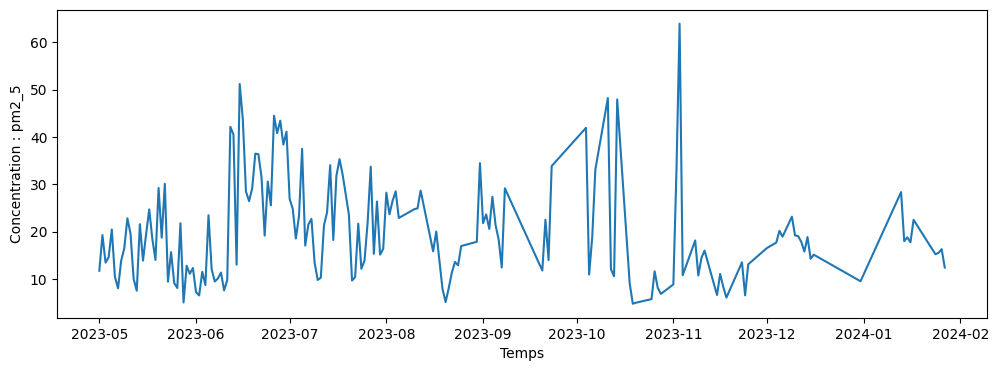

In [10]:
# TODO 6: create a figure, call plot_daily_trend once per city, label and show it
figure,ax= plt.subplots(1,1,figsize=(12,4))
ax= plot_daily_trend(standard, 'Nairobi', ax)
plt.show()


**Exercise:** Same trend, with a single [`seaborn.lineplot()`](https://seaborn.pydata.org/generated/seaborn.lineplot.html) call — no manual aggregation needed, it works directly on the raw `df`. You already used the `data=`/`x=`/`y=`/`hue=` pattern for the boxplot, so no need to re-derive it: reuse it directly with `x="date"`, `y="pm2_5"`, `hue="city"`.

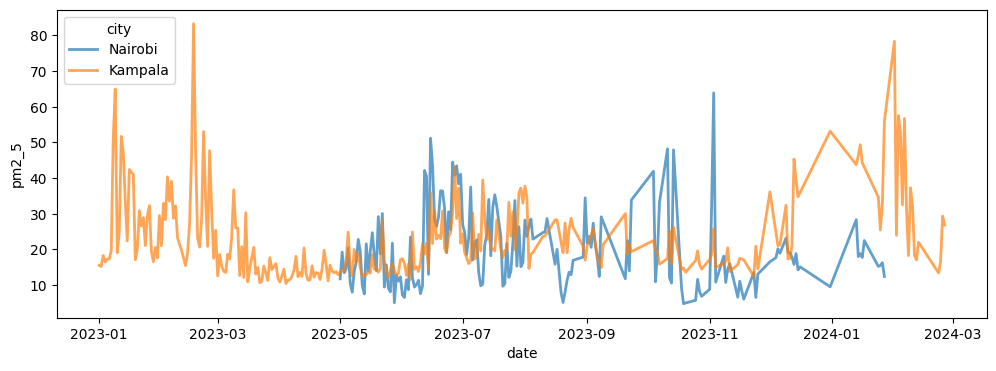

In [11]:
# TODO 7: same trend, with a single seaborn.lineplot call (aggregation + confidence interval included)
plt.figure(figsize=(12,4))

sns.lineplot(
    data=df,
    x='date',
    y='pm2_5',
    hue='city',
    linewidth=2,
    errorbar=None,
    alpha=0.7,
)
plt.show()

## 4. Missing values

Before any modeling, you need to know what you don't have. Two views: how much is missing per column overall (matplotlib bar chart), and whether it differs between cities (seaborn heatmap) — a difference here could mean a sensor issue specific to one city, rather than a shared satellite-retrieval limitation.

**Documentation references:**
- [`DataFrame.isna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)
- [`seaborn.heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

**Exercise:** For each column, you need the *fraction* of missing values, then turned into a percentage. `DataFrame.isna()` flags every cell as `True`/`False` — think about what averaging a column of `True`/`False` values gives you (hint: `True` behaves like 1 and `False` like 0). Keep only columns with at least one missing value, and plot them as a matplotlib bar chart, sorted from most to least missing.

Text(9.444444444444445, 0.5, 'percentage')

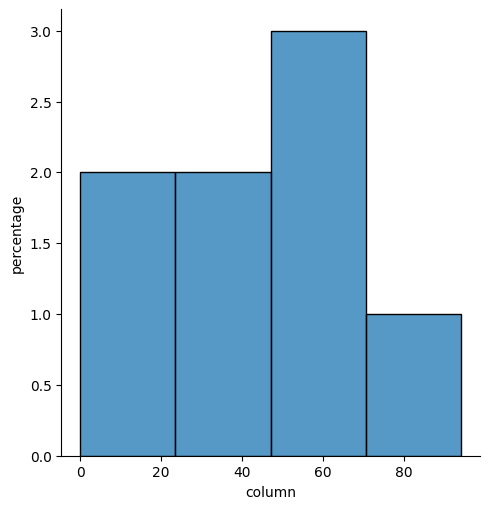

In [12]:
# TODO 8: bar chart of the percentage of missing values per column, with matplotlib
missing_values= (df.isna().mean())*100
missing_values_count = missing_values[missing_values>0.01]
sns.displot(missing_values_count)
plt.xlabel("column")
plt.ylabel("percentage")

**Exercise:** Same information, broken down by city this time, as a `seaborn.heatmap` — one row per city, one column per variable, cell values annotated in %.

<Axes: >

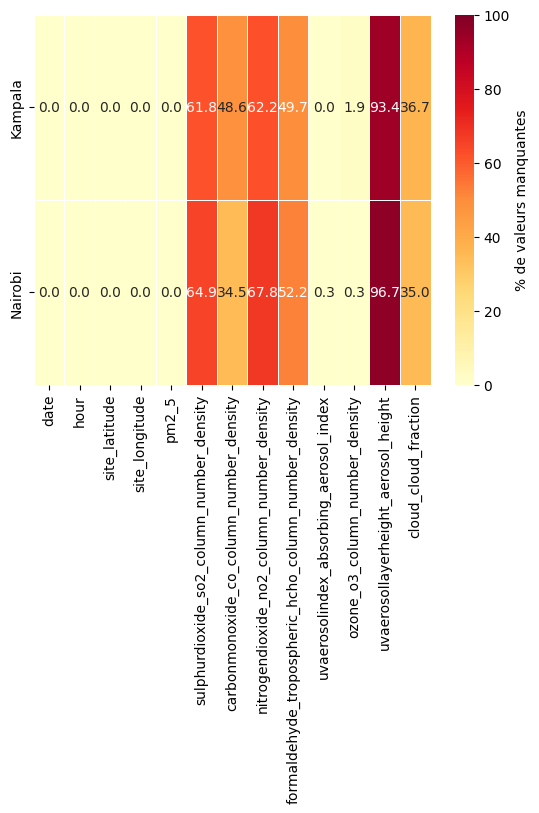

In [ ]:
# TODO 9: same information, broken down by city, with a seaborn heatmap
rows= 'city'
columns= df.columns.drop('city')
index=['Kampala','Nairobi']
d={}
for id in index:
    filtered_df = df[df['city'] == id]
    filtered_df = filtered_df.drop(columns='city')
    L=filtered_df.isna().mean()*100
    L=L.to_list()
    d[id]=L
"""
df.set_index('city)
df.groupby('city).isna().mean*100 ...
"""
    
heatmap= pd.DataFrame(data=d,index=columns).T
sns.heatmap(
    data=heatmap,
    annot=True,              # Affiche les pourcentages exacts dans chaque cellule
    fmt=".1f",              # Formate à 1 décimale (ex: 23.4%)
    cmap="YlOrRd",           # Palette séquentielle : jaune (faible) vers rouge foncé (critique)
    vmin=0,                  # Borne min fixée à 0%
    vmax=100,                # Borne max fixée à 100%
    linewidths=0.5,          # Sépare nettement les cellules
    cbar_kws={'label': '% de valeurs manquantes'}
)    


## 5. Correlation with `pm2_5`

A quick way to get a first impression of which variables might matter: a correlation heatmap. Treat it as a lead, not a conclusion — a bare coefficient does not tell you whether the relationship is statistically reliable, nor whether it is even linear in the first place. Session 3 has a dedicated module that does this properly (Pearson vs. Spearman, p-values, and the right way to handle missing data when comparing many variables at once) — this is deliberately just the quick version.

**Documentation references:**
- [`DataFrame.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
- [`seaborn.heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

**Exercise:** Compute the correlation matrix of the 8 satellite columns plus `pm2_5` — `DataFrame.corr()` already handles missing values pairwise on its own, no `dropna` needed here — and display it as an annotated `seaborn.heatmap`.

<Axes: >

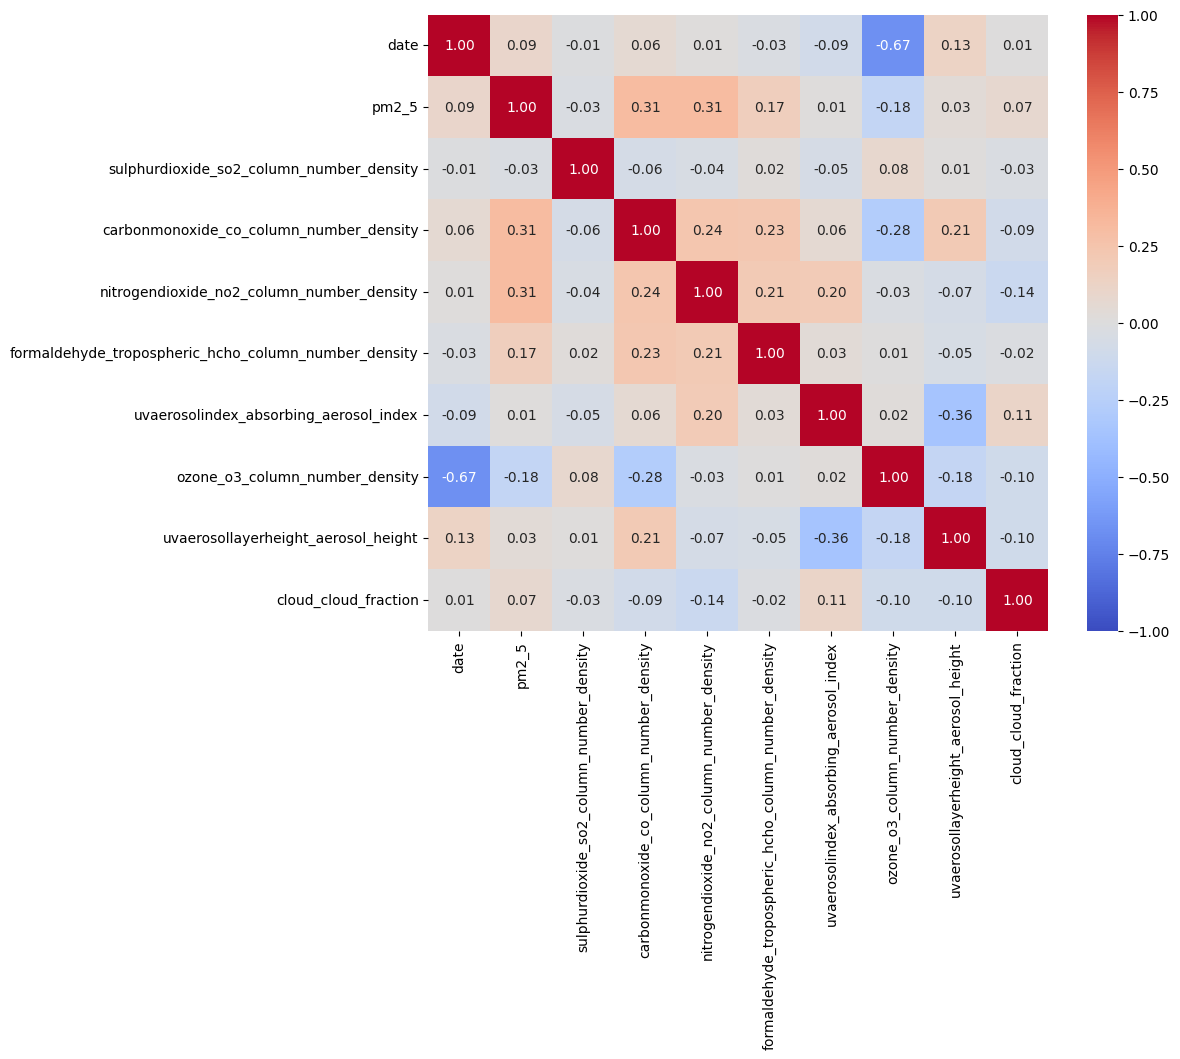

In [75]:
# TODO 10: correlation heatmap of the satellite columns and pm2_5
satellite_cols= [col for col in df.columns if col not in['city','site_latitude','hour','site_longitude'] ]
df_corr= df[satellite_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr,
    annot=True,          # Requis par la consigne ("annotated")
    fmt=".2f",          # 2 décimales pour les coefficients de Pearson
    cmap="coolwarm",     # Palette divergente (bleu = négatif, rouge = positif)
    vmin=-1,             # Borne min théorique d'une corrélation
    vmax=1,              # Borne max théorique
)

## Wrap-up

Write down 3-4 observations or hypotheses that seem worth investigating further in the next activity (*Build a First Pipeline*): which variable looks most promising, whether the two cities look comparable, and anything about missing data that a cleaning step should handle carefully.

_Your observations here._